In [1]:
def flatten_dataset(dataset):
    data_df = pd.DataFrame(dataset)
    answers = pd.json_normalize(data_df['answers'])
    df_answers = pd.DataFrame()
    data_df['answer_text'] = None
    df_answers['pos_answer'] = None
    data_df['ra'] = data_df['ra'].astype(int)
    for c in range(len(answers.columns)):
        answer = pd.json_normalize(answers[c])
        df_answers = pd.concat([df_answers, answer['atext']], axis=1)
        df_answers.rename(columns={'atext': c + 1}, inplace=True)
    for i in range(data_df.shape[0]):
        col = data_df.loc[i, 'ra']
        data_df.loc[i, 'answer_text'] = df_answers.iloc[i, col]
    df_answers['pos_answer'] = df_answers.apply(lambda x: '\n '.join(x.dropna().astype(str)), axis=1)
    data_df = pd.concat([data_df, df_answers], axis=1)
    return data_df

In [2]:
!pip -q install transformers datasets

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
import nltk
from datasets import load_dataset

In [4]:
from google.colab import userdata
sec_key = userdata.get('HF_TOKEN')

In [5]:
!huggingface-cli login --token $sec_key

The token has not been saved to the git credentials helper. Pass `add_to_git_credential=True` in this function directly or `--add-to-git-credential` if using via `huggingface-cli` if you want to set the git credential as well.
Token is valid (permission: fineGrained).
Your token has been saved to /root/.cache/huggingface/token
Login successful


In [6]:
# The instruction dataset to use
dataset_name = "head_qa"
dataset_train = load_dataset(dataset_name, split="train", trust_remote_code=True)
dataset_val = load_dataset(dataset_name, split="validation", trust_remote_code=True)
dataset_test = load_dataset(dataset_name, split="test", trust_remote_code=True)

In [7]:
dataset_train[0]

{'name': 'Cuaderno_2013_1_B',
 'year': '2013',
 'category': 'biology',
 'qid': 1,
 'qtext': 'Los potenciales postsinápticos excitadores:',
 'ra': 3,
 'image': None,
 'answers': [{'aid': 1, 'atext': 'Son de tipo todo o nada.'},
  {'aid': 2, 'atext': 'Son hiperpolarizantes.'},
  {'aid': 3, 'atext': 'Se pueden sumar.'},
  {'aid': 4, 'atext': 'Se propagan a largas distancias.'},
  {'aid': 5, 'atext': 'Presentan un periodo refractario.'}]}

In [8]:
train_df = flatten_dataset(dataset_train)
val_df = flatten_dataset(dataset_val)
test_df = flatten_dataset(dataset_test)

In [9]:
train_df.head()

,name,year,category,qid,qtext,ra,image,answers,answer_text,pos_answer,1,2,3,4,5
0,Cuaderno_2013_1_B,2013,biology,1,Los potenciales postsinápticos excitadores:,3,None,"[{'aid': 1, 'atext': 'Son de tipo todo o nada....",Se pueden sumar.,Son de tipo todo o nada.\n Son hiperpolarizant...,Son de tipo todo o nada.,Son hiperpolarizantes.,Se pueden sumar.,Se propagan a largas distancias.,Presentan un periodo refractario.
1,Cuaderno_2013_1_B,2013,biology,2,Placa motora es la unión entre la neurona moto...,2,None,"[{'aid': 1, 'atext': 'Músculo liso.'}, {'aid':...",Músculo esquelético.,Músculo liso.\n Músculo esquelético.\n Músculo...,Músculo liso.,Músculo esquelético.,Músculo cardiaco.,Huso muscular.,Tendón.
2,Cuaderno_2013_1_B,2013,biology,3,NO generan potenciales de acción:,2,None,"[{'aid': 1, 'atext': 'Fibras musculares lisas....",Neuronas bipolares de la retina.,Fibras musculares lisas.\n Neuronas bipolares ...,Fibras musculares lisas.,Neuronas bipolares de la retina.,Fibras musculares estriadas esqueléticas.,Fibras musculares cardíacas.,Neuronas ganglionares de la retina.
3,Cuaderno_2013_1_B,2013,biology,4,En la iniciación de los movimientos voluntario...,1,None,"[{'aid': 1, 'atext': 'Corteza premotora.'}, {'...",Corteza premotora.,Corteza premotora.\n Corteza motora primaria.\...,Corteza premotora.,Corteza motora primaria.,Tallo cerebral.,Cerebelo.,Ganglios basales.
4,Cuaderno_2013_1_B,2013,biology,5,Los corpúsculos de Pacini:,4,None,"[{'aid': 1, 'atext': 'Están inervados por fibr...",Se localizan en zonas profundas de la dermis.,Están inervados por fibras amielínicas.\n Son ...,Están inervados por fibras amielínicas.,Son mecanorreceptores de adaptación lenta.,Presentan campos receptores pequeños.,Se localizan en zonas profundas de la dermis.,Son termorreceptores.


In [10]:
train_df['full_question'] = train_df['qtext'] + '\n ' + train_df['pos_answer']
val_df['full_question'] = val_df['qtext'] + '\n ' + val_df['pos_answer']
test_df['full_question'] = test_df['qtext'] + '\n ' + test_df['pos_answer']

In [11]:
train_df['full_question'] = train_df['full_question'].str.lower()
val_df['full_question'] = val_df['full_question'].str.lower()
test_df['full_question'] = test_df['full_question'].str.lower()

In [12]:
train_df = pd.concat([train_df, val_df, test_df])

In [13]:
import re
train_df['full_question'] = train_df['full_question'].map(lambda x: re.sub(r'\W+', ' ', x))

In [14]:
train_df['full_question']

,full_question
0,los potenciales postsinápticos excitadores son...
1,placa motora es la unión entre la neurona moto...
2,no generan potenciales de acción fibras muscul...
3,en la iniciación de los movimientos voluntario...
4,los corpúsculos de pacini están inervados por ...
...,...
2737,a qué estructura tipo corresponde la definici...
2738,el na2b2o7 se utiliza como patrón primario en ...
2739,cuál es el color del indicador fenolftaleína ...
2740,qué indicador se utiliza en la valoración del...


## Número de caracteres por pregunta en train_df

In [15]:
train_df['full_question'].str.len().describe()

,full_question
count,6765.000000
mean,326.714265
std,216.917632
min,34.000000
25%,179.000000
50%,264.000000
75%,409.000000
max,2277.000000


<Axes: >

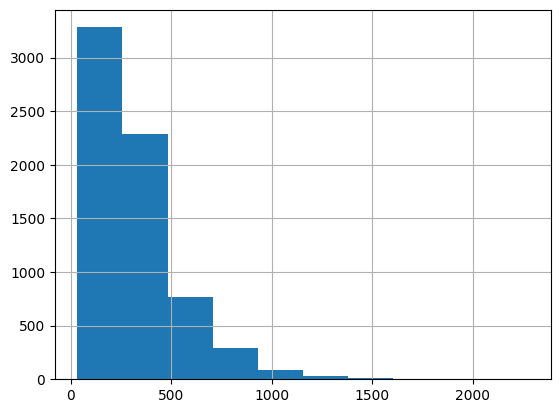

In [16]:
train_df['full_question'].str.len().hist()

## Número de palabras por pregunta en train_df

In [17]:
train_df['full_question'].str.split().map(lambda x: len(x)).describe()

,full_question
count,6765.000000
mean,50.383444
std,35.139351
min,7.000000
25%,26.000000
50%,40.000000
75%,63.000000
max,372.000000


<Axes: >

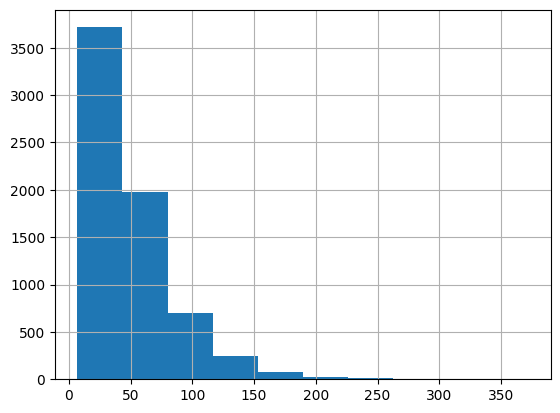

In [18]:
train_df['full_question'].str.split().map(lambda x: len(x)).hist()

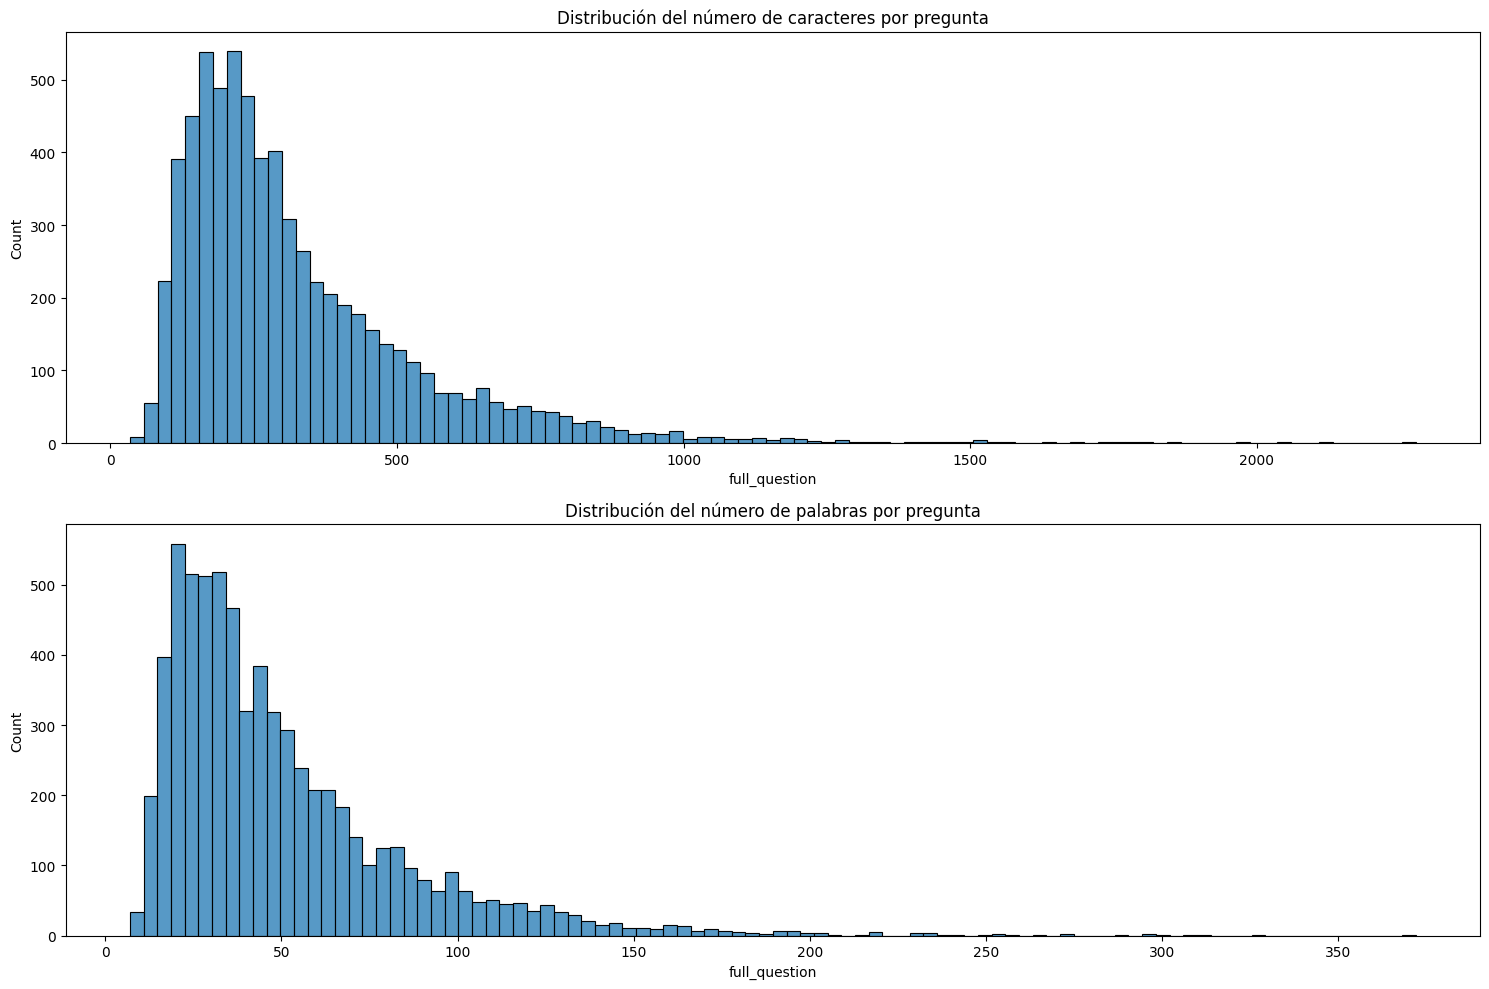

In [19]:
fig, axs = plt.subplots(2,1, figsize=(15, 10))
sns.histplot(train_df['full_question'].str.len(), ax=axs[0])
axs[0].set_title('Distribución del número de caracteres por pregunta')
sns.histplot(train_df['full_question'].str.split().map(lambda x: len(x)), ax=axs[1])
axs[1].set_title('Distribución del número de palabras por pregunta')
plt.tight_layout()

## Análisis de Stop words

In [20]:
from nltk.corpus import stopwords
nltk.download('stopwords')
stop=set(stopwords.words('spanish'))

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [21]:
corpus = []
pregunta = train_df['full_question'].str.split()
pregunta = pregunta.values.tolist()
corpus = [word for i in pregunta for word in i]
from collections import defaultdict
dic = defaultdict(int)
for word in corpus:
    if word in stop:
        dic[word]+=1

In [22]:
df_stopwords = pd.DataFrame.from_dict(dic, orient='index')
df_stopwords.reset_index(inplace=True)
df_stopwords.columns = ['Palabra', 'Conteo']
df_stopwords.sort_values(by='Conteo', ascending=False, inplace=True)
df_stopwords.head()

,Palabra,Conteo
2,de,29192
10,la,16963
13,el,8765
15,en,8712
12,y,6306


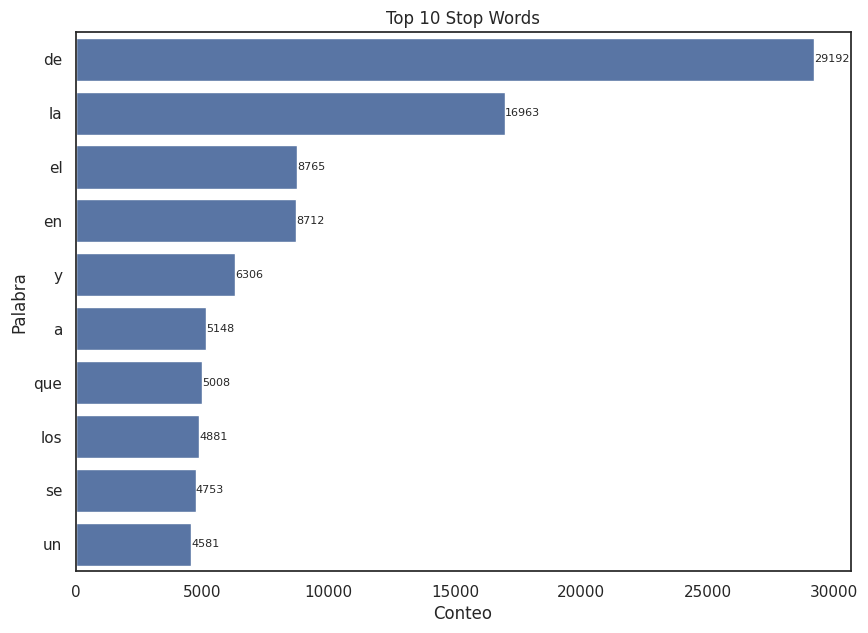

In [23]:
sns.set_theme(style="white", context="notebook")
fig, ax = plt.subplots(figsize=(10, 7))
ax = sns.barplot(data=df_stopwords.sort_values('Conteo', ascending=False).head(10),
                 x='Conteo',
                 y='Palabra',
                 #hue='Palabra',
                 #palette="Spectral",
                 )
ax.bar_label(ax.containers[0], fontsize=8)

plt.title('Top 10 Stop Words')
plt.show()

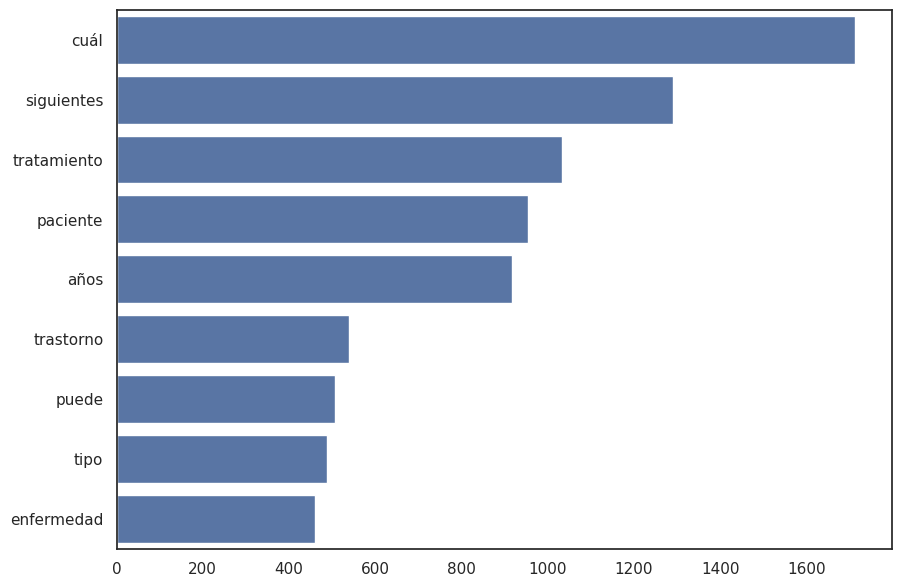

In [24]:
from collections import Counter
counter = Counter(corpus)
most = counter.most_common()

x, y = [], []
for word, count in most[:40]:
    if (word not in stop) and not (word.isnumeric()):
        x.append(word)
        y.append(count)

sns.set_theme(style="white", context="notebook")
fig, ax = plt.subplots(figsize=(10, 7))
ax = sns.barplot(x=y, y=x)

In [25]:
from sklearn.feature_extraction.text import CountVectorizer
def get_top_ngram(corpus, n=None):
    vec = CountVectorizer(ngram_range=(n, n)).fit(corpus)
    bag_of_words = vec.transform(corpus)
    sum_words = bag_of_words.sum(axis=0)
    words_freq = [(word, sum_words[0, idx])
                  for word, idx in vec.vocabulary_.items()]
    words_freq =sorted(words_freq, key = lambda x: x[1], reverse=True)
    df_ngrams = pd.DataFrame(words_freq, columns=['n-gram', 'Conteo'])
    return df_ngrams[:10]

In [26]:
n_grams = get_top_ngram(train_df['full_question'], 3)
n_grams

,n-gram,Conteo
0,de las siguientes,643
1,cuál de las,582
2,de los siguientes,493
3,cuál de los,467
4,cuál es el,199
5,cuál es la,184
6,el tratamiento de,178
7,las siguientes afirmaciones,166
8,pregunta vinculada la,165
9,vinculada la imagen,165


<Axes: xlabel='Conteo', ylabel='n-gram'>

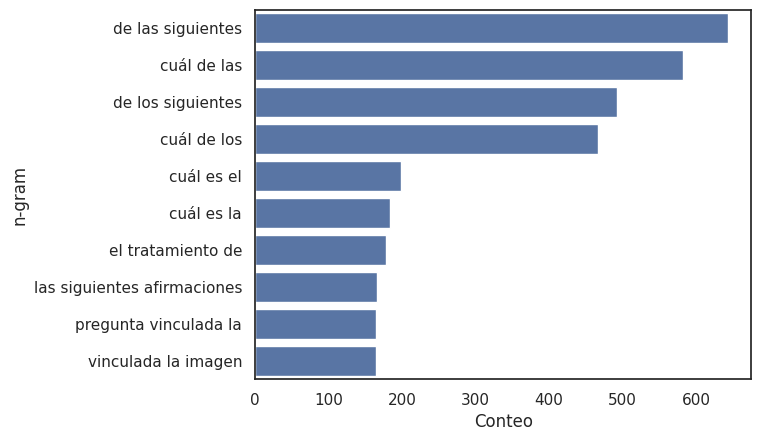

In [27]:
sns.barplot(data=n_grams, y='n-gram', x='Conteo')

## Análisis por categoría de pregunta

In [28]:
train_df.category.unique()

array(['biology', 'nursery', 'pharmacology', 'medicine', 'psychology',
       'chemistry'], dtype=object)

In [29]:
n_grams_medicina = get_top_ngram(train_df.loc[train_df['category'] == 'medicine', 'full_question'], 3)
n_grams_medicina['Categoría'] = 'Medicina'
n_grams_medicina

,n-gram,Conteo,Categoría
0,de las siguientes,215,Medicina
1,cuál de las,193,Medicina
2,pregunta vinculada la,165,Medicina
3,vinculada la imagen,165,Medicina
4,años de edad,117,Medicina
5,de los siguientes,115,Medicina
6,cuál de los,101,Medicina
7,cuál es el,93,Medicina
8,diagnóstico más probable,85,Medicina
9,el diagnóstico más,82,Medicina


In [30]:
n_grams_biology = get_top_ngram(train_df.loc[train_df['category'] == 'biology', 'full_question'], 3)
n_grams_biology['Categoría'] = 'Biología'
n_grams_biology

,n-gram,Conteo,Categoría
0,la secreción de,30,Biología
1,de los siguientes,27,Biología
2,virus de la,26,Biología
3,cuál de los,25,Biología
4,la síntesis de,24,Biología
5,de los linfocitos,24,Biología
6,de las siguientes,21,Biología
7,cuál de las,20,Biología
8,las células de,18,Biología
9,de la membrana,17,Biología


In [31]:
n_grams_nursery = get_top_ngram(train_df.loc[train_df['category'] == 'nursery', 'full_question'], 3)
n_grams_nursery['Categoría'] = 'Enfermería'
n_grams_nursery

,n-gram,Conteo,Categoría
0,de las siguientes,122,Enfermería
1,cuál de las,93,Enfermería
2,de los siguientes,72,Enfermería
3,cuál de los,63,Enfermería
4,señale la respuesta,61,Enfermería
5,la respuesta correcta,47,Enfermería
6,de la salud,45,Enfermería
7,la administración de,36,Enfermería
8,de atención primaria,33,Enfermería
9,cuál es la,33,Enfermería


In [32]:
n_grams_pharmacology = get_top_ngram(train_df.loc[train_df['category'] == 'pharmacology', 'full_question'], 3)
n_grams_pharmacology['Categoría'] = 'Farmacología'
n_grams_pharmacology

,n-gram,Conteo,Categoría
0,cuál de los,141,Farmacología
1,de los siguientes,141,Farmacología
2,de las siguientes,130,Farmacología
3,cuál de las,118,Farmacología
4,el tratamiento de,47,Farmacología
5,la síntesis de,44,Farmacología
6,en el tratamiento,40,Farmacología
7,la velocidad de,34,Farmacología
8,cuál es el,30,Farmacología
9,las siguientes afirmaciones,28,Farmacología


In [33]:
n_grams_psychology = get_top_ngram(train_df.loc[train_df['category'] == 'psychology', 'full_question'], 3)
n_grams_psychology['Categoría'] = 'Psicología'
n_grams_psychology

<ipython-input-33-2de77963ab13>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  n_grams_psychology['Categoría'] = 'Psicología'


,n-gram,Conteo,Categoría
0,de los siguientes,87,Psicología
1,de las siguientes,86,Psicología
2,cuál de las,83,Psicología
3,cuál de los,81,Psicología
4,el tratamiento de,52,Psicología
5,el trastorno de,49,Psicología
6,de la personalidad,44,Psicología
7,en el tratamiento,44,Psicología
8,la terapia de,44,Psicología
9,de la conducta,42,Psicología


In [34]:
n_grams_chemistry = get_top_ngram(train_df.loc[train_df['category'] == 'chemistry', 'full_question'], 3)
n_grams_chemistry['Categoría'] = 'Química'
n_grams_chemistry

,n-gram,Conteo,Categoría
0,cuál de las,75,Química
1,de las siguientes,69,Química
2,cuál de los,56,Química
3,de los siguientes,51,Química
4,la formación de,42,Química
5,la reacción de,42,Química
6,la síntesis de,39,Química
7,la concentración de,32,Química
8,un electrodo de,29,Química
9,la velocidad de,29,Química


In [35]:
df_3_grams = pd.concat([n_grams_medicina,
                        n_grams_biology,
                        n_grams_nursery,
                        n_grams_pharmacology,
                        n_grams_psychology,
                        n_grams_chemistry])

df_3_grams.head()

,n-gram,Conteo,Categoría
0,de las siguientes,215,Medicina
1,cuál de las,193,Medicina
2,pregunta vinculada la,165,Medicina
3,vinculada la imagen,165,Medicina
4,años de edad,117,Medicina


In [36]:
df_3_grams = df_3_grams.sort_values(by='Conteo', ascending=True)
df_3_grams.head()

,n-gram,Conteo,Categoría
9,de la membrana,17,Biología
8,las células de,18,Biología
7,cuál de las,20,Biología
6,de las siguientes,21,Biología
4,la síntesis de,24,Biología


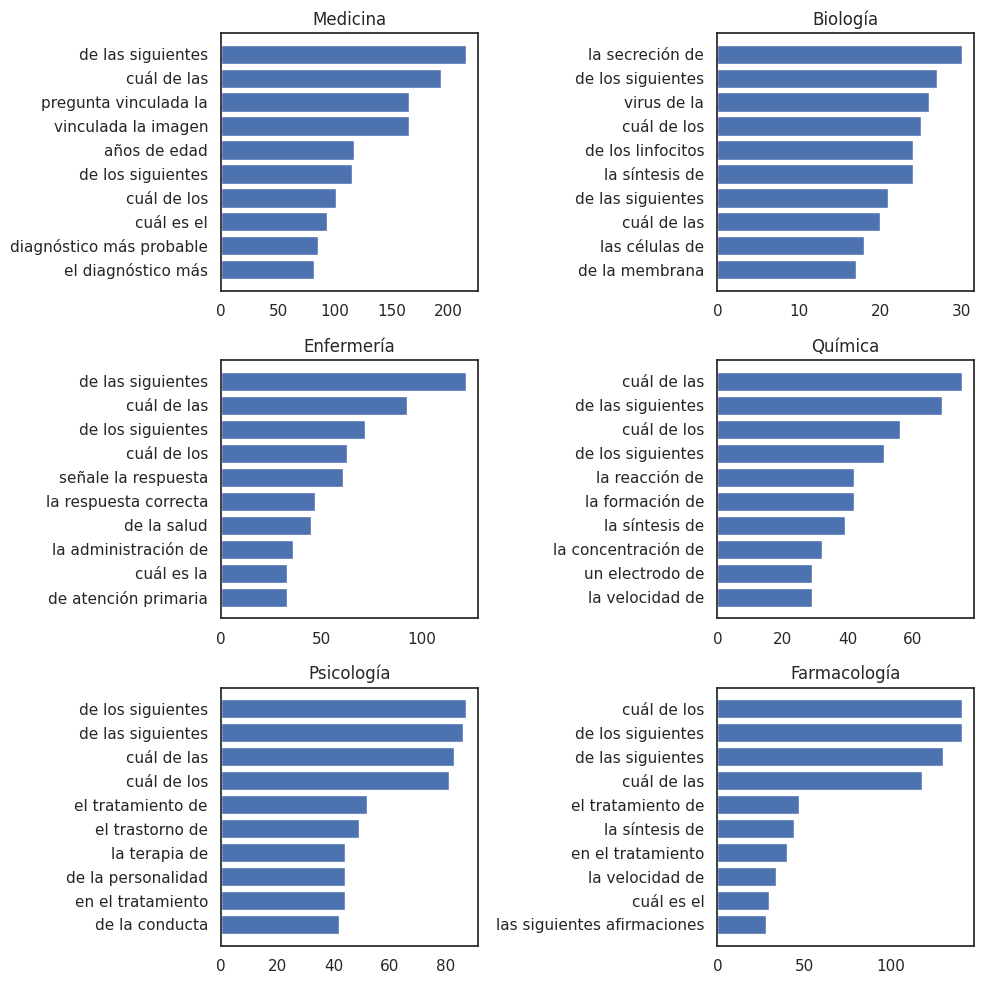

In [44]:
fig, axs = plt.subplots(3, 2, figsize=(10, 10))

axs[0][0].barh(y=df_3_grams.loc[df_3_grams['Categoría'] == 'Medicina', 'n-gram'],
            width=df_3_grams.loc[df_3_grams['Categoría'] == 'Medicina', 'Conteo'])
axs[0][0].set_title('Medicina')

axs[0][1].barh(df_3_grams.loc[df_3_grams['Categoría'] == 'Biología', 'n-gram'],
            df_3_grams.loc[df_3_grams['Categoría'] == 'Biología', 'Conteo'])
axs[0][1].set_title('Biología')

axs[1][0].barh(df_3_grams.loc[df_3_grams['Categoría'] == 'Enfermería', 'n-gram'],
            df_3_grams.loc[df_3_grams['Categoría'] == 'Enfermería', 'Conteo'])
axs[1][0].set_title('Enfermería')

axs[1][1].barh(df_3_grams.loc[df_3_grams['Categoría'] == 'Química', 'n-gram'],
            df_3_grams.loc[df_3_grams['Categoría'] == 'Química', 'Conteo'])
axs[1][1].set_title('Química')

axs[2][0].barh(df_3_grams.loc[df_3_grams['Categoría'] == 'Psicología', 'n-gram'],
            df_3_grams.loc[df_3_grams['Categoría'] == 'Psicología', 'Conteo'])
axs[2][0].set_title('Psicología')

axs[2][1].barh(df_3_grams.loc[df_3_grams['Categoría'] == 'Farmacología', 'n-gram'],
            df_3_grams.loc[df_3_grams['Categoría'] == 'Farmacología', 'Conteo'])
axs[2][1].set_title('Farmacología')
plt.tight_layout()